# Кейс №12: Урал — Атырау

Прогноз среднесуточного уровня на один день. Реальные архивные наблюдения 2018, 2019, 2022. Этот Notebook выполняет обучение; результаты не вставлены вручную. Помощь ИИ раскрывается в общем пакете. Источники и ограничения: [DATA_CARD.md](DATA_CARD.md), [References.md](References.md).

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
CASE = Path.cwd()
if not (CASE / 'dataset.csv').exists():
    CASE = CASE / '03_Water_Monitoring'
assert (CASE / 'dataset.csv').exists(), 'Запустите из папки кейса или корня пакета'
sys.path.insert(0, str(CASE / 'code'))
import pipeline
print('Python:', sys.version.split()[0])
print('scikit-learn:', pipeline.sklearn.__version__)

Python: 3.12.14
scikit-learn: 1.9.1


## Данные и контроль извлечения

Единица — гидропост-день. Включён числовой архив, а полные PDF с неустановленной открытой лицензией не распространяются. Повтор извлечения: `python code/prepare_data.py --download --cache <папка>`.

In [2]:
df = pd.read_csv(CASE / 'dataset.csv', parse_dates=['date'])
display(df.head())
display(df.groupby('source_year').agg(days=('level_cm','size'), mean_cm=('level_cm','mean'), minimum=('level_cm','min'), maximum=('level_cm','max')))
quality = json.loads((CASE / 'results/data_quality.json').read_text(encoding='utf-8'))
print(json.dumps(quality, ensure_ascii=False, indent=2))
display(pd.read_csv(CASE / 'results/extraction_validation.csv'))

,date,station_id,level_cm,source_marks,source_year,source_page,source_id
0,2018-01-01,19802,248,I,2018,35,W2018
1,2018-01-02,19802,246,I,2018,35,W2018
2,2018-01-03,19802,243,I,2018,35,W2018
3,2018-01-04,19802,239,I,2018,35,W2018
4,2018-01-05,19802,236,_I,2018,35,W2018


,days,mean_cm,minimum,maximum
source_year,,,,
2018,365,270.495890,180,413
2019,365,241.378082,153,324
2022,365,219.909589,144,375


{
  "rows": 1095,
  "unique_dates": 1095,
  "missing_level": 0,
  "duplicate_dates": 0,
  "years": [
    2018,
    2019,
    2022
  ],
  "omitted_years": [
    2020,
    2021
  ],
  "monthly_mean_checks_passed": 36,
  "monthly_mean_max_abs_difference_cm": 0.5,
  "dataset_sha256": "155f74f0043c12047402032fdeac1cc7eedc51dcb192ffb3c77f31d20a81f1d1",
  "raw_extracted_sha256": "155f74f0043c12047402032fdeac1cc7eedc51dcb192ffb3c77f31d20a81f1d1"
}


,year,month,published_mean_cm,computed_mean_cm,absolute_difference_cm,pass
0,2018,1,250,250.354839,0.354839,True
1,2018,2,260,260.178571,0.178571,True
2,2018,3,262,261.580645,0.419355,True
3,2018,4,313,312.633333,0.366667,True
4,2018,5,375,375.483871,0.483871,True
5,2018,6,315,314.900000,0.100000,True
6,2018,7,282,281.709677,0.290323,True
7,2018,8,258,257.677419,0.322581,True
8,2018,9,245,245.433333,0.433333,True
9,2018,10,245,245.483871,0.483871,True


## Протокол и обучение

Train — 2018; validation — 2019; test — 2022. Все измеряемые признаки сдвинуты в прошлое, лаги не пересекают отсутствующие 2020–2021. В начале 2019 доступны предыдущие дни 2018. Выбор по validation MAE. Следующая ячейка заново обучает шесть кандидатов, фиксирует выбор, переобучает два финальных метода и оценивает test.

In [3]:
summary = pipeline.run()
print(json.dumps(summary, ensure_ascii=False, indent=2))
display(pd.read_csv(CASE / 'results/validation_search.csv'))
display(pd.read_csv(CASE / 'results/metrics.csv'))

{
  "selected_model": "ridge",
  "validation_selected_MAE_cm": 6.59580409915196,
  "test_selected": {
    "n": 358,
    "MAE_cm": 7.038741591180133,
    "RMSE_cm": 10.57721053048693,
    "R2": 0.9634455304724913
  },
  "test_baseline": {
    "n": 358,
    "MAE_cm": 6.966480446927374,
    "RMSE_cm": 10.751899923051147,
    "R2": 0.9622281187860725
  },
  "MAE_improvement_percent": -1.0372690313748114,
  "largest_error_date": "2022-03-05",
  "largest_error_cm": 81.69499169842834,
  "annual": [
    {
      "source_year": 2018,
      "n": 365,
      "mean_cm": 270.4958904109589,
      "min_cm": 180,
      "max_cm": 413,
      "std_cm": 48.389026882396784
    },
    {
      "source_year": 2019,
      "n": 365,
      "mean_cm": 241.37808219178083,
      "min_cm": 153,
      "max_cm": 324,
      "std_cm": 28.355660357923007
    },
    {
      "source_year": 2022,
      "n": 365,
      "mean_cm": 219.9095890410959,
      "min_cm": 144,
      "max_cm": 375,
      "std_cm": 55.01782968840063
   

,model,parameter,n,MAE_cm,RMSE_cm,R2
0,persistence,none,365,7.106849,9.890635,0.878000
1,drift,none,365,8.561644,12.414861,0.807781
2,ridge,0.1,365,6.884112,9.822115,0.879684
3,ridge,1,365,6.876879,9.810201,0.879976
4,ridge,10,365,6.817995,9.728695,0.881962
5,ridge,100,365,6.595804,9.478169,0.887963
6,forest,3,365,6.679926,9.318487,0.891706
7,forest,10,365,6.692157,9.351101,0.890947


,split,model,n,MAE_cm,RMSE_cm,R2
0,validation,persistence,365,7.106849,9.890635,0.878000
1,validation,drift,365,8.561644,12.414861,0.807781
2,validation,ridge,365,6.595804,9.478169,0.887963
3,validation,forest,365,6.679926,9.318487,0.891706
4,test,persistence,358,6.966480,10.751900,0.962228
5,test,drift,358,8.910615,13.980633,0.936137
6,test,ridge,358,7.038742,10.577211,0.963446
7,test,forest,358,7.015622,10.808571,0.961829


## EDA на фактическом ряде

Три года не образуют непрерывного климатического ряда. Месячные различия не доказывают долговременный тренд.

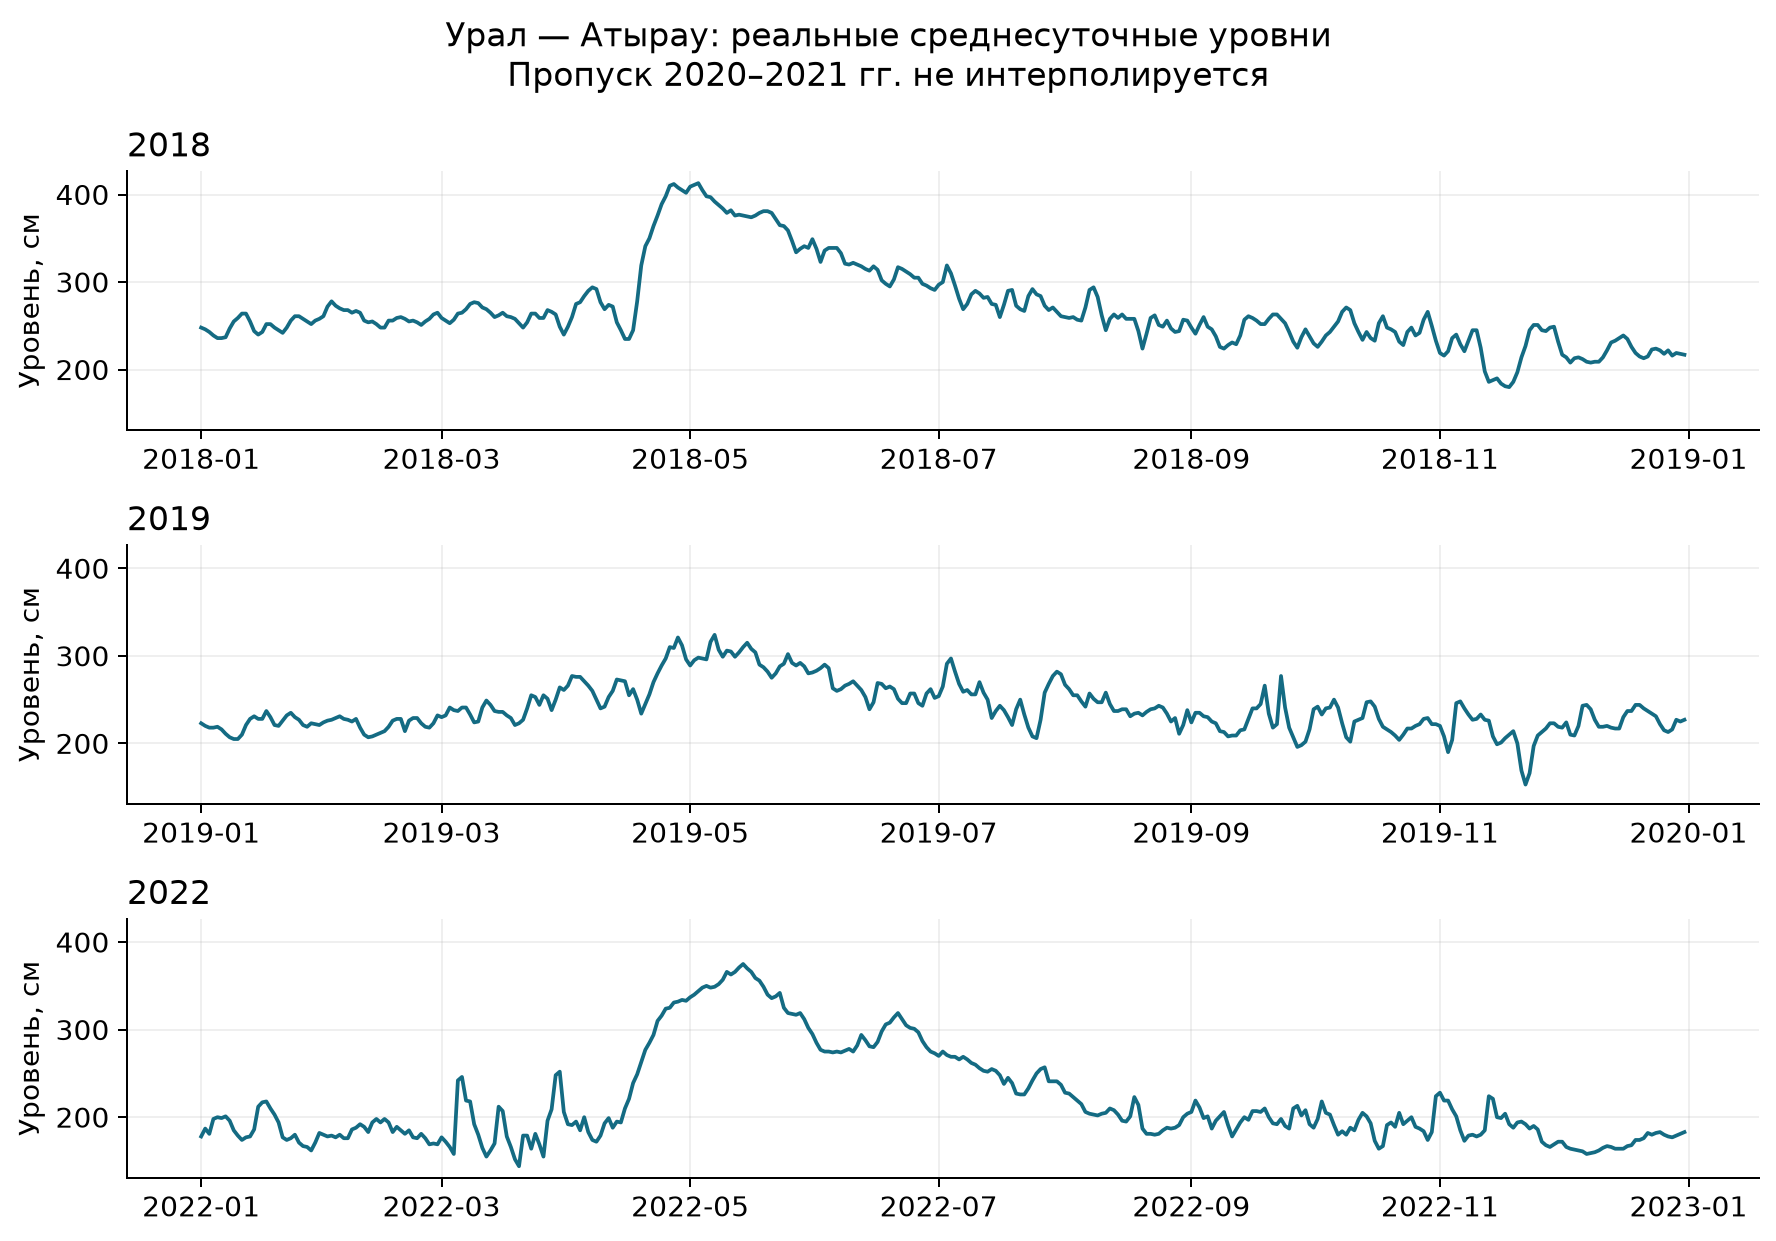

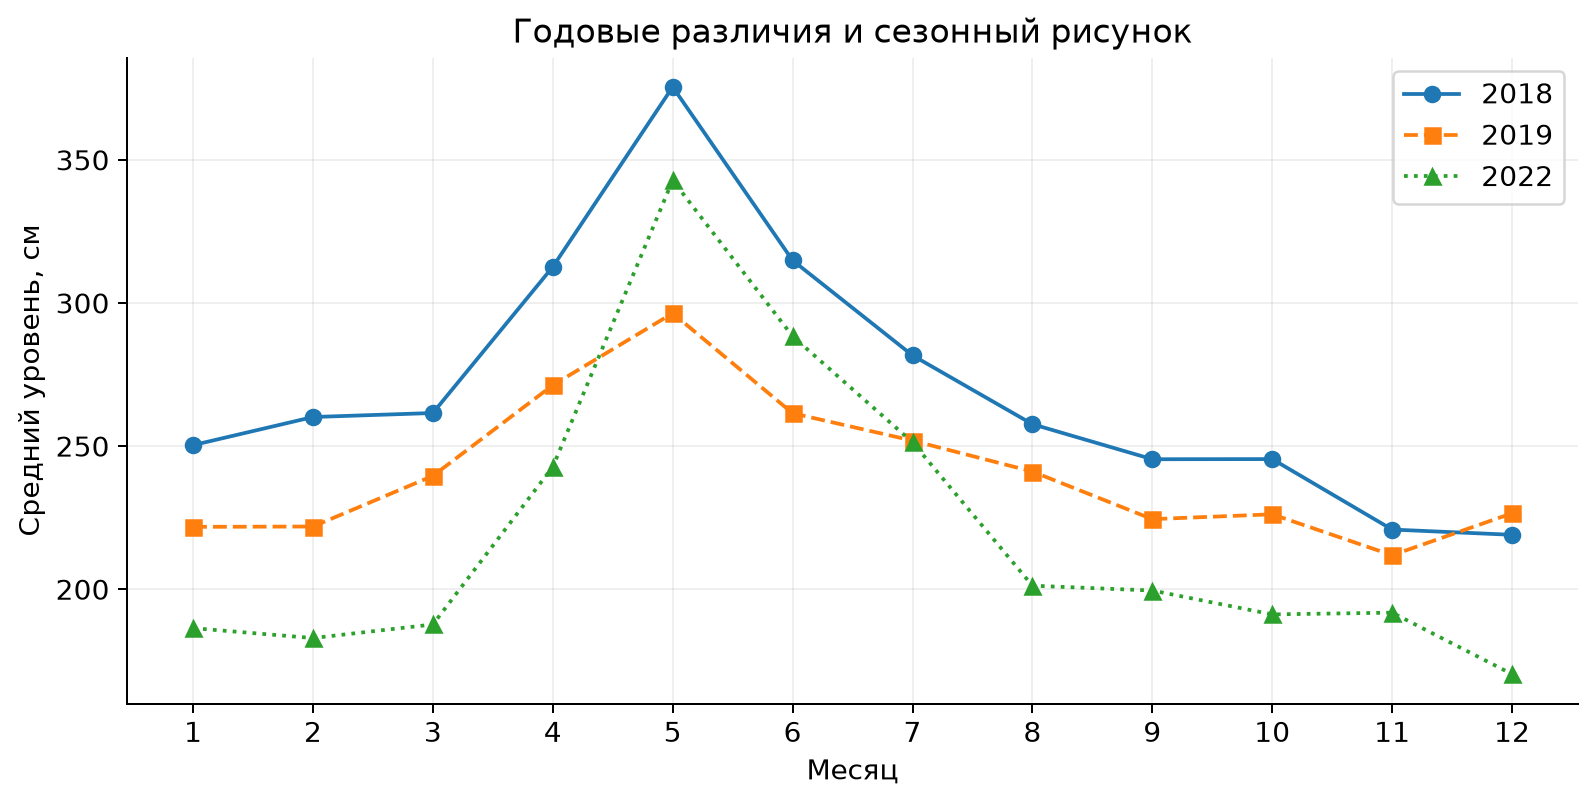

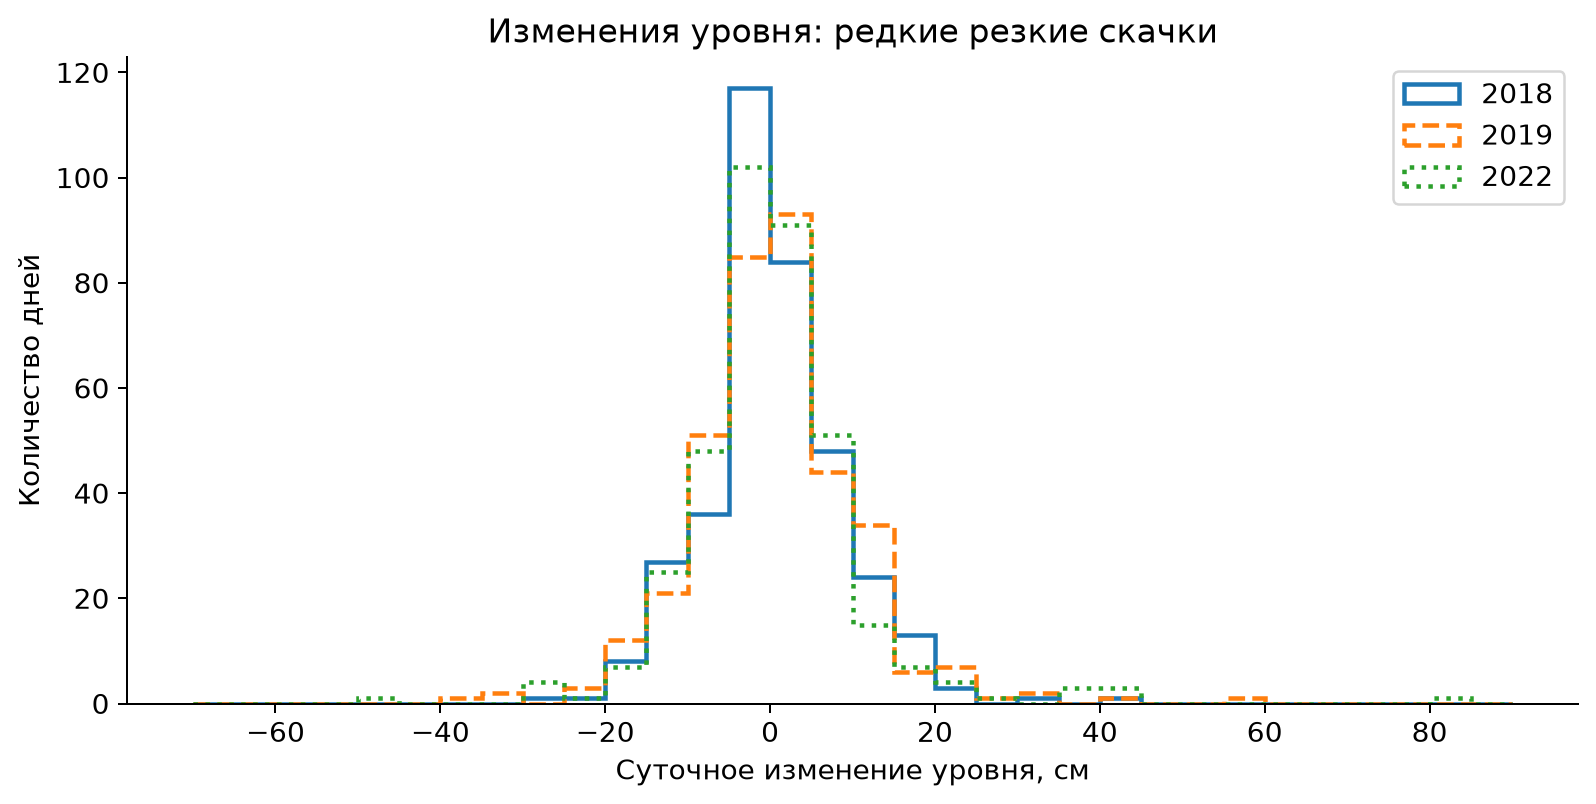

In [4]:
for name in ['01_daily_levels.png','02_monthly_levels.png','03_daily_changes.png']:
    display(Image(filename=str(CASE / 'figures' / name), width=900))

## Отложенная оценка и ошибки

Основной вывод определяется MAE. Высокий R² не заменяет сравнение с persistence. Ни параметры, ни состав test после оценки не изменяются.

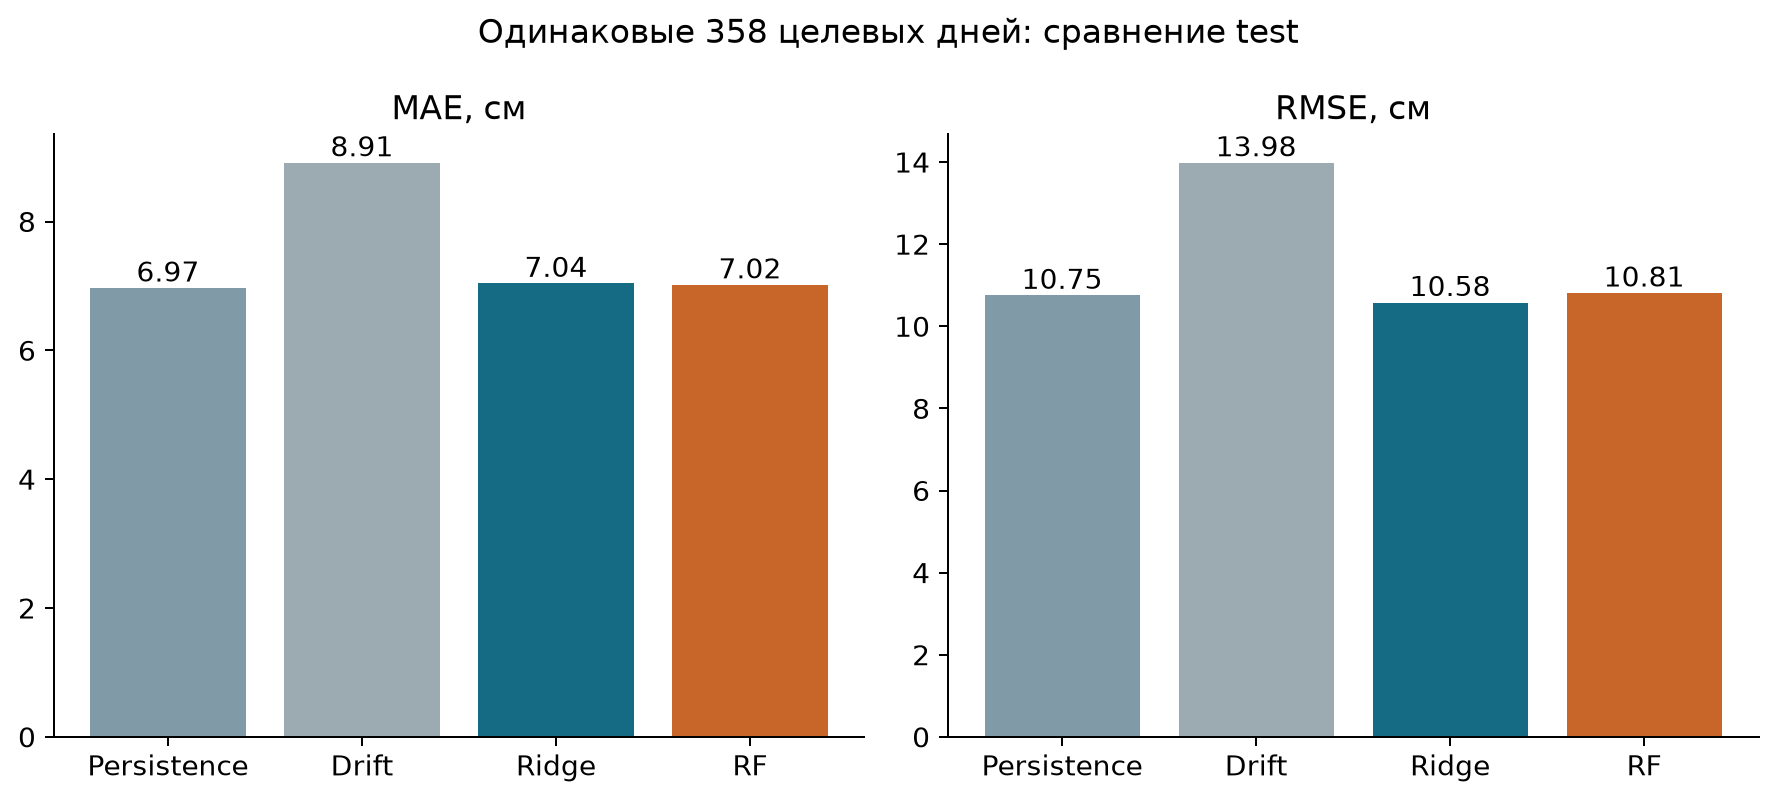

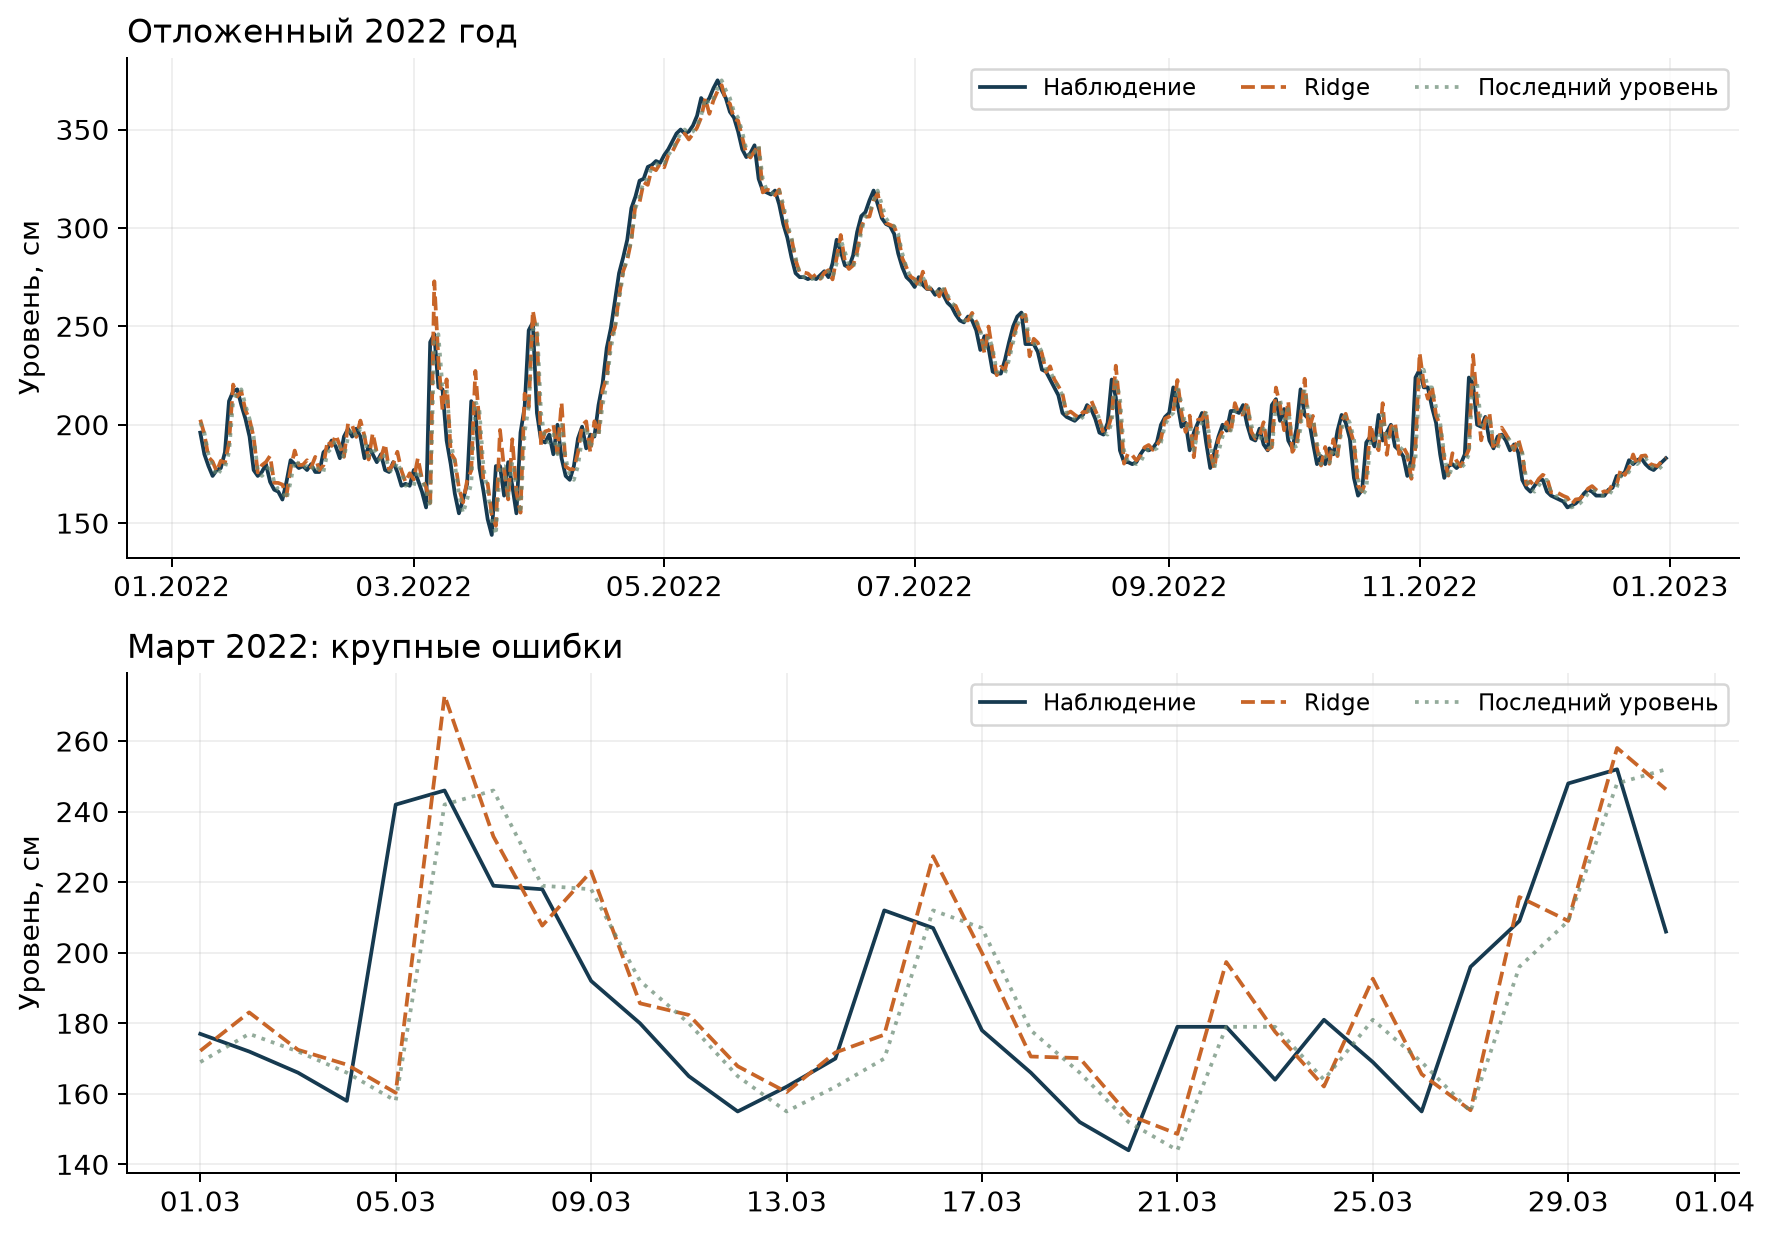

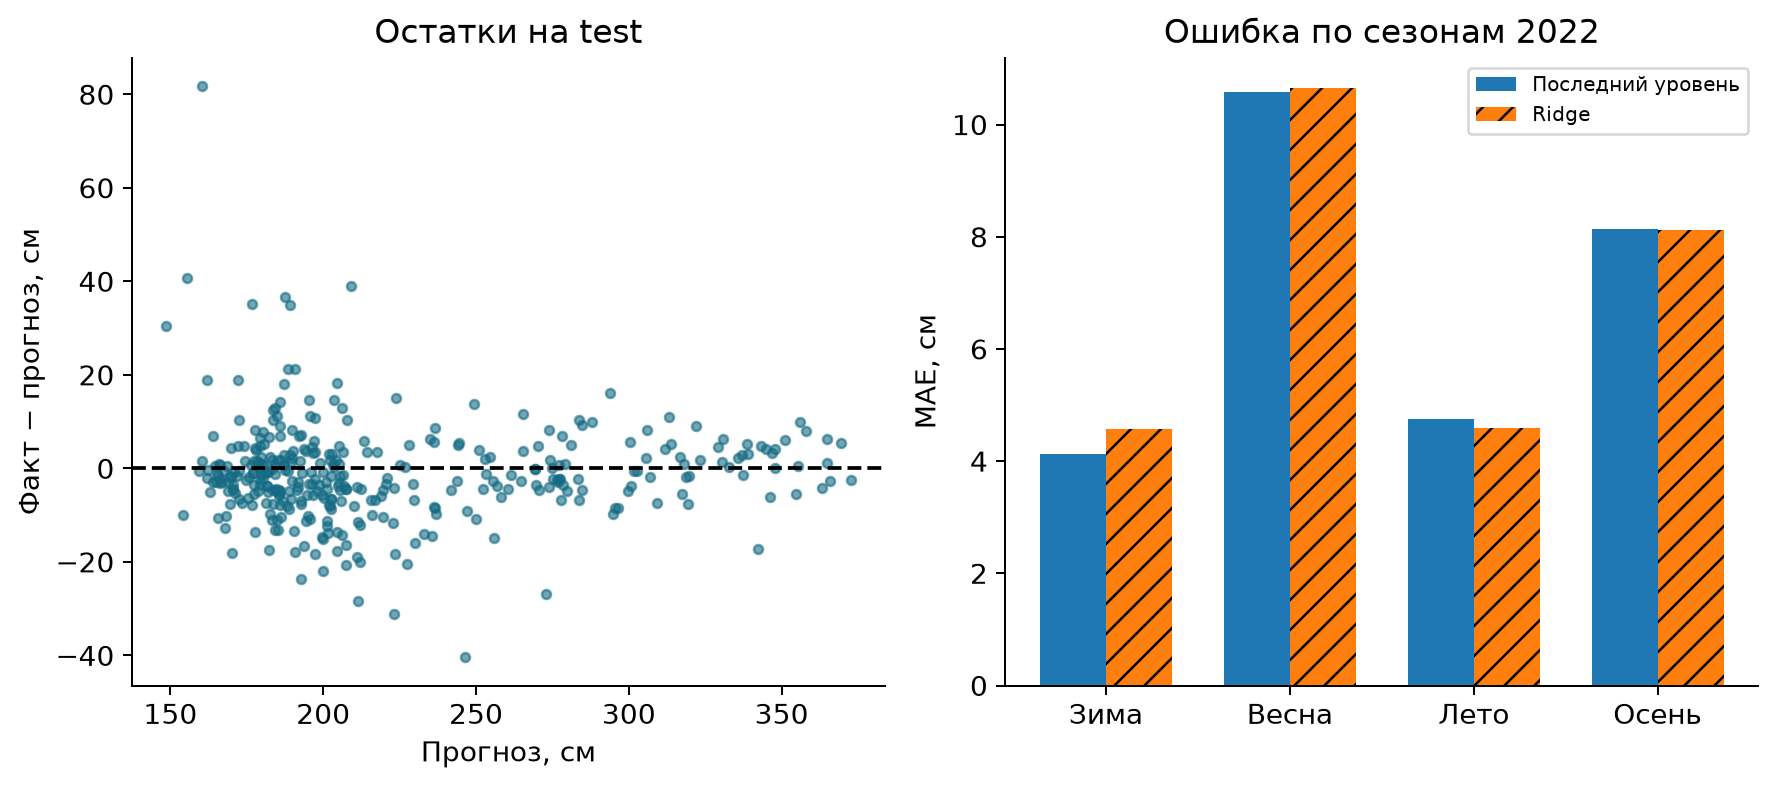

,forecast_origin_date,target_time,actual,split,persistence,drift,ridge,forest,selected,month,season,error_cm,absolute_error_cm
0,2022-03-04,2022-03-05,242,test,158.0,150.0,160.305008,156.808801,160.305008,3,Весна,81.694992,81.694992
1,2022-03-26,2022-03-27,196,test,155.0,141.0,155.339682,152.675083,155.339682,3,Весна,40.660318,40.660318
2,2022-03-30,2022-03-31,206,test,252.0,256.0,246.324315,254.495435,246.324315,3,Весна,-40.324315,40.324315
3,2022-03-28,2022-03-29,248,test,209.0,222.0,209.028501,216.662349,209.028501,3,Весна,38.971499,38.971499
4,2022-11-12,2022-11-13,224,test,185.0,190.0,187.440892,187.786343,187.440892,11,Осень,36.559108,36.559108
5,2022-03-14,2022-03-15,212,test,170.0,178.0,176.759365,177.747295,176.759365,3,Весна,35.240635,35.240635
6,2022-10-30,2022-10-31,224,test,183.0,192.0,189.147112,188.422112,189.147112,10,Осень,34.852888,34.852888
7,2022-03-08,2022-03-09,192,test,218.0,217.0,223.058331,219.853113,223.058331,3,Весна,-31.058331,31.058331
8,2022-03-20,2022-03-21,179,test,144.0,136.0,148.627544,147.639124,148.627544,3,Весна,30.372456,30.372456
9,2022-04-05,2022-04-06,183,test,200.0,215.0,211.260746,216.303530,211.260746,4,Весна,-28.260746,28.260746


,season,model,n,MAE_cm,RMSE_cm,R2
0,Весна,persistence,92,10.586957,16.151457,0.954714
1,Весна,ridge,92,10.658287,15.995979,0.955581
2,Зима,persistence,83,4.132530,5.773850,0.798060
3,Зима,ridge,83,4.569112,5.979694,0.783405
4,Лето,persistence,92,4.750000,6.506686,0.971129
5,Лето,ridge,92,4.583706,6.019834,0.975287
6,Осень,persistence,91,8.131868,10.855697,0.409315
7,Осень,ridge,91,8.113955,10.592448,0.437615


Изменение MAE относительно persistence, %: -1.0373


In [5]:
for name in ['05_model_comparison.png','04_actual_vs_predicted.png','06_errors_seasons.png']:
    display(Image(filename=str(CASE / 'figures' / name), width=900))
display(pd.read_csv(CASE / 'results/largest_errors.csv'))
display(pd.read_csv(CASE / 'results/seasonal_metrics.csv'))
print('Изменение MAE относительно persistence, %:', round(summary['MAE_improvement_percent'], 4))

## Исторический replay

Флаг основан на 99-м процентиле прошлых абсолютных изменений. Это не порог опасности. Последний прогноз на 01.01.2023 не оценивается; истинных меток аварий нет.

In [6]:
from replay import replay
print(json.dumps(replay(), ensure_ascii=False, indent=2))
actions = pd.read_csv(CASE / 'results/replay_actions.csv')
display(actions.head(10))
display(actions[actions.statistical_flag])

{
  "rows": 365,
  "predictions": 359,
  "statistical_flags": 8,
  "quality_failures": 0,
  "threshold_cm": 31.0,
  "threshold_source": "99th percentile absolute daily change on 2018+2019 only",
  "threshold_operator": ">",
  "hazard_classification": false,
  "labeled_anomaly_metrics": "not applicable; no anomaly labels",
  "actions_sent": false,
  "last_forecast_has_no_observed_target": true
}


,observation_date,level_cm,quality,delta_cm,threshold_abs_change_cm,statistical_flag,target_time,prediction_next_day_cm,proposed_action,mode
0,2022-01-01,178,valid,NaN,31.0,False,2022-01-02,NaN,routine_observation,historical_replay_not_live_iot
1,2022-01-02,187,valid,9.0,31.0,False,2022-01-03,NaN,routine_observation,historical_replay_not_live_iot
2,2022-01-03,181,valid,-6.0,31.0,False,2022-01-04,NaN,routine_observation,historical_replay_not_live_iot
3,2022-01-04,198,valid,17.0,31.0,False,2022-01-05,NaN,routine_observation,historical_replay_not_live_iot
4,2022-01-05,200,valid,2.0,31.0,False,2022-01-06,NaN,routine_observation,historical_replay_not_live_iot
5,2022-01-06,199,valid,-1.0,31.0,False,2022-01-07,NaN,routine_observation,historical_replay_not_live_iot
6,2022-01-07,201,valid,2.0,31.0,False,2022-01-08,202.566480,routine_observation,historical_replay_not_live_iot
7,2022-01-08,196,valid,-5.0,31.0,False,2022-01-09,195.168599,routine_observation,historical_replay_not_live_iot
8,2022-01-09,185,valid,-11.0,31.0,False,2022-01-10,183.521193,routine_observation,historical_replay_not_live_iot
9,2022-01-10,179,valid,-6.0,31.0,False,2022-01-11,181.290347,routine_observation,historical_replay_not_live_iot


,observation_date,level_cm,quality,delta_cm,threshold_abs_change_cm,statistical_flag,target_time,prediction_next_day_cm,proposed_action,mode
63,2022-03-05,242,valid,84.0,31.0,True,2022-03-06,272.893808,check_measurement_and_context_manually,historical_replay_not_live_iot
73,2022-03-15,212,valid,42.0,31.0,True,2022-03-16,227.355517,check_measurement_and_context_manually,historical_replay_not_live_iot
79,2022-03-21,179,valid,35.0,31.0,True,2022-03-22,197.364051,check_measurement_and_context_manually,historical_replay_not_live_iot
85,2022-03-27,196,valid,41.0,31.0,True,2022-03-28,215.783879,check_measurement_and_context_manually,historical_replay_not_live_iot
87,2022-03-29,248,valid,39.0,31.0,True,2022-03-30,258.051227,check_measurement_and_context_manually,historical_replay_not_live_iot
89,2022-03-31,206,valid,-46.0,31.0,True,2022-04-01,189.804391,check_measurement_and_context_manually,historical_replay_not_live_iot
303,2022-10-31,224,valid,41.0,31.0,True,2022-11-01,236.483423,check_measurement_and_context_manually,historical_replay_not_live_iot
316,2022-11-13,224,valid,39.0,31.0,True,2022-11-14,235.491624,check_measurement_and_context_manually,historical_replay_not_live_iot


## Проверки и итог

Пересчитываются метрики из CSV, сравниваются последовательные и пакетные прогнозы, проверяются разбиение, хеши и исходные месячные средние.

In [7]:
display(pd.DataFrame(pipeline.verify()))
print(f"Ridge MAE: {summary['test_selected']['MAE_cm']:.3f} см; baseline: {summary['test_baseline']['MAE_cm']:.3f} см")
print('Преимущество выбранной модели по test MAE не подтверждено.')

,check,status
0,schema_unique_dates_finite_numeric,PASS
1,strictly_past_observations,PASS
2,target_split_disjoint,PASS
3,metrics_recomputed_from_saved_predictions,PASS
4,36_source_monthly_mean_checks,PASS
5,model_dataset_hash,PASS
6,sequential_replay_matches_batch_predictions,PASS


Ridge MAE: 7.039 см; baseline: 6.966 см
Преимущество выбранной модели по test MAE не подтверждено.


## Ограничения

Один пост, три выбранных по доступности года; отсутствие данных 2020–2021; неизвестная оперативная задержка суточного среднего и конкретная автоматизация поста; нет внешних прогнозов погоды и меток опасных событий. Нельзя утверждать живую IoT-интеграцию, предотвращённый ущерб или фактическую экономию воды. Студент должен самостоятельно проверить и понимать эксперимент перед защитой.